# Shop Sphere exploratory data analysis (EDA)

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from operator import attrgetter


In [3]:
df = pd.read_csv('ShopSphere_Dataset.csv')

In [4]:
df.head()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States


In [5]:
# Bottom 5 rows
df.tail()

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country
385309,420989,2024-10-11 09:01:10,14371,40623,Groceries,35,20.17,United States
385310,420989,2024-10-11 09:01:10,14371,40504,Sports & Outdoors,54,37.31,United States
385311,420989,2024-10-11 09:01:10,14371,40189,Home & Living,83,18.24,United States
385312,420989,2024-10-11 09:01:10,14371,40299,Beauty & Wellness,100,39.94,United States
385313,420989,2024-10-11 09:01:10,14371,40029,Fashion,86,27.04,United States


In [6]:
## Data dimension to see rows and features
df.shape

(385314, 8)

In [7]:
## feature analysis
df.columns

Index(['InvoiceNo', 'InvoiceDate', 'CustomerID', 'StockCode', 'Description',
       'Quantity', 'UnitPrice', 'Country'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385314 entries, 0 to 385313
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    385314 non-null  int64  
 1   InvoiceDate  385314 non-null  object 
 2   CustomerID   385314 non-null  int64  
 3   StockCode    385314 non-null  int64  
 4   Description  385314 non-null  object 
 5   Quantity     385314 non-null  int64  
 6   UnitPrice    385314 non-null  float64
 7   Country      385314 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 23.5+ MB


In [9]:
### No missing data compared with the shape analysis of 385314 rows

In [10]:
### Statistical analysis: Based on mean of quantity sold compared with 50% percentile (median), data is uniformly distributed 
df.describe()

,InvoiceNo,CustomerID,StockCode,Quantity,UnitPrice
count,385314.000000,385314.000000,385314.000000,385314.000000,385314.000000
mean,410481.180074,12178.170819,40339.113494,50.503283,46.416868
std,6066.054690,1264.763846,239.679387,26.674684,41.658811
min,400000.000000,10000.000000,40000.000000,1.000000,1.000000
25%,405223.000000,11078.000000,40127.000000,31.000000,16.370000
50%,410453.000000,12151.000000,40288.000000,51.000000,33.590000
75%,415747.000000,13285.000000,40559.000000,70.000000,62.310000
max,420989.000000,14371.000000,40799.000000,100.000000,384.900000


In [11]:
### Categorical analysis : Showed Order from United States if more frequent with Fashion been the most
df.describe(include=['object'])

,InvoiceDate,Description,Country
count,385314,385314,385314
unique,20980,10,2
top,2024-08-20 21:04:36,Fashion,United States
freq,50,69110,308618


## Data Cleaning & Feature Engineering


In [12]:
null_vals = df.isnull().sum()
null_vals
df.drop_duplicates(inplace=True)
# Remove invalid rows
df = df[(df['Quantity'] > 0)]
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df = df[(df['Revenue'] > 0)]

### Profit cannot be calculated from the data, missing unit cost

### Date conversion
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

## Extract year, month, quarter into separate columns
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Quarter'] = df['InvoiceDate'].dt.quarter

df.head(20)

,InvoiceNo,InvoiceDate,CustomerID,StockCode,Description,Quantity,UnitPrice,Country,Revenue,Year,Month,Quarter
0,400000,2024-01-21 03:01:47,10000,40565,Groceries,31,5.56,United Kingdom,172.36,2024,1,1
1,400000,2024-01-21 03:01:47,10000,40048,Fashion,14,34.86,United Kingdom,488.04,2024,1,1
2,400000,2024-01-21 03:01:47,10000,40149,Electronics,48,149.66,United States,7183.68,2024,1,1
3,400000,2024-01-21 03:01:47,10000,40514,Sports & Outdoors,7,38.30,United States,268.10,2024,1,1
4,400000,2024-01-21 03:01:47,10000,40607,Groceries,4,7.66,United States,30.64,2024,1,1
5,400000,2024-01-21 03:01:47,10000,40787,Automotive,6,114.25,United Kingdom,685.50,2024,1,1
6,400000,2024-01-21 03:01:47,10000,40156,Electronics,18,270.07,United Kingdom,4861.26,2024,1,1
7,400000,2024-01-21 03:01:47,10000,40149,Electronics,1,120.80,United Kingdom,120.80,2024,1,1
8,400000,2024-01-21 03:01:47,10000,40128,Electronics,1,147.43,United States,147.43,2024,1,1
9,400000,2024-01-21 03:01:47,10000,40088,Electronics,60,112.11,United States,6726.60,2024,1,1


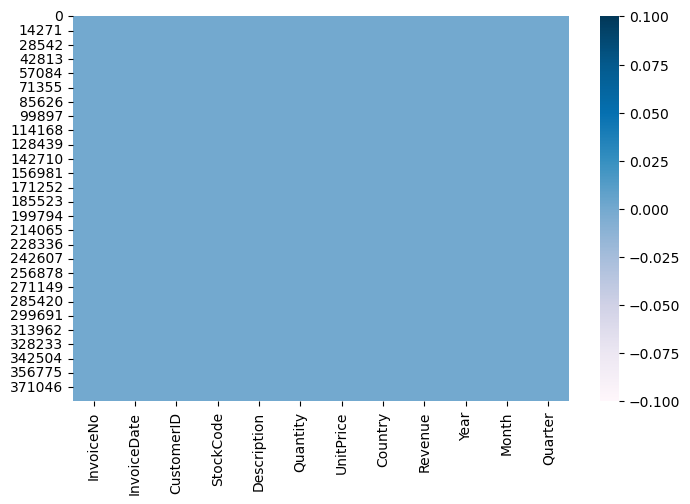

In [13]:
plt.figure(figsize = (8,5))
sns.heatmap(df.isnull(), cbar=True, cmap='PuBu');


### Data Analysis

In [14]:
### Customer age segmentation --- Since there is an hypothetical customer table, this is ignored

### Univariate Analysis


In [15]:
df['CustomerID'] = df['CustomerID'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385314 entries, 0 to 385313
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    385314 non-null  int64         
 1   InvoiceDate  385314 non-null  datetime64[ns]
 2   CustomerID   385314 non-null  object        
 3   StockCode    385314 non-null  int64         
 4   Description  385314 non-null  object        
 5   Quantity     385314 non-null  int64         
 6   UnitPrice    385314 non-null  float64       
 7   Country      385314 non-null  object        
 8   Revenue      385314 non-null  float64       
 9   Year         385314 non-null  int32         
 10  Month        385314 non-null  int32         
 11  Quarter      385314 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(3), object(3)
memory usage: 30.9+ MB


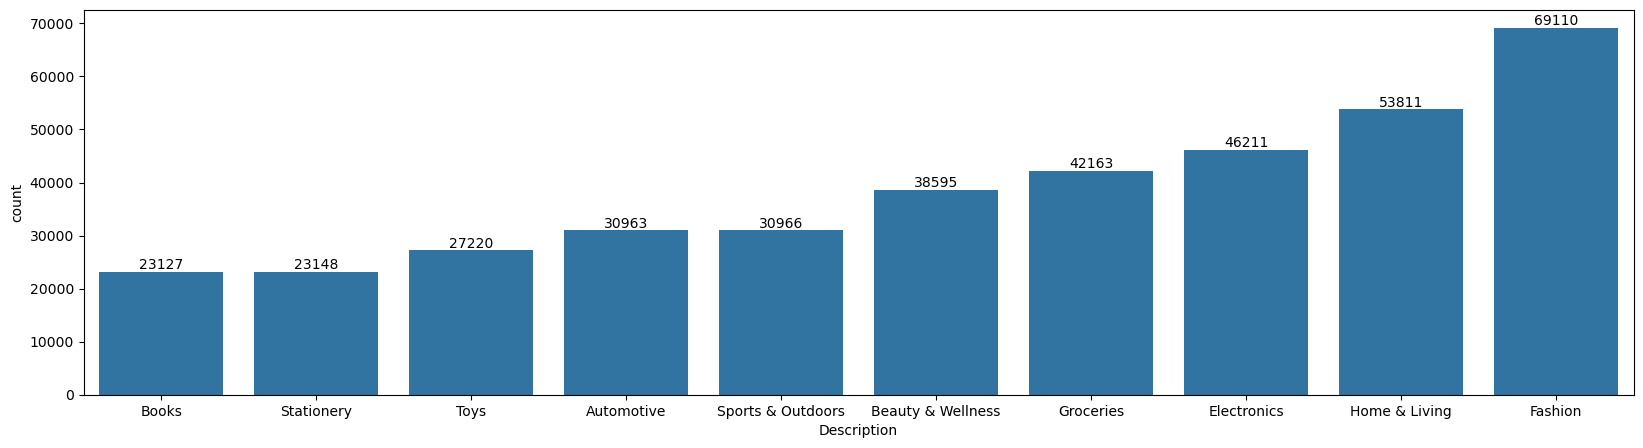

In [16]:
plt.figure(figsize=(20,5))
ax = sns.countplot(x=df['Description'], order=df['Description'].value_counts(ascending=True).index)
values = df['Description'].value_counts(ascending=True).values
ax.bar_label(container=ax.containers[0], labels=values);

##### Product description volume:
Fashion has the highest sale 
Books and Stationary showed the lowest sold categories

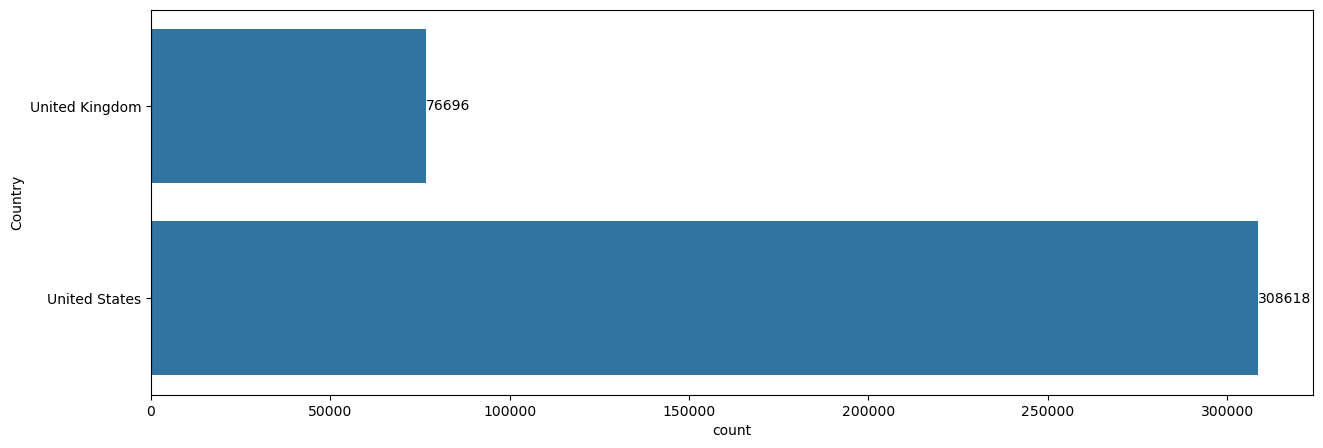

In [17]:
#### Transaction by country
plt.figure(figsize=(15,5))
country_counts = df['Country'].value_counts(ascending=True)
                                            
ax = sns.countplot(y=df['Country'], order=country_counts.index)
values = df['Country'].value_counts(ascending=False).values
ax.bar_label(container=ax.containers[0], labels=country_counts.values);

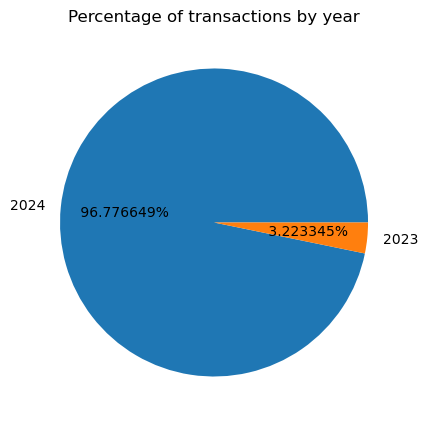

In [18]:
##### Transaction volume by year
from collections import Counter
fig,ax = plt.subplots(figsize=(5,5))
count = Counter(df['Year'])
ax.set_title('Percentage of transactions by year')
ax.pie(count.values(), labels=count.keys(), autopct=lambda p:f'{p: 2f}%');

### Bivariate analysis       

In [19]:
number_of_customers = df['CustomerID'].nunique()
number_of_transactions = df['InvoiceNo'].nunique()
date_range = (df['InvoiceDate'].min(), df['InvoiceDate'].max())

In [20]:
print(f'Total Unique customers: {number_of_customers}')
print(f'Number of Unique transactions: {number_of_transactions}')
print(f'Date range of dataset: {date_range}')

Total Unique customers: 4372
Number of Unique transactions: 20990
Date range of dataset: (Timestamp('2023-12-01 00:25:31'), Timestamp('2024-12-31 23:52:56'))


In [21]:
print(f'None positive quantity: ', (df['Quantity'] <= 0).sum())
print(f'None positive unit price :', (df['UnitPrice'] <= 0).sum())

None positive quantity:  0
None positive unit price : 0


In [22]:
average_revenue = df['Revenue'].mean();
print('average revenue is: ', {average_revenue})

average revenue is:  {np.float64(2341.7934992499618)}


In [23]:
top_selling_countrys = df.groupby('Country')['CustomerID'].nunique().sort_values(ascending=False)
print('Country by number of customers')
print(top_selling_countrys)

Country by number of customers
Country
United States     4372
United Kingdom    4359
Name: CustomerID, dtype: int64


In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 385314 entries, 0 to 385313
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    385314 non-null  int64         
 1   InvoiceDate  385314 non-null  datetime64[ns]
 2   CustomerID   385314 non-null  object        
 3   StockCode    385314 non-null  int64         
 4   Description  385314 non-null  object        
 5   Quantity     385314 non-null  int64         
 6   UnitPrice    385314 non-null  float64       
 7   Country      385314 non-null  object        
 8   Revenue      385314 non-null  float64       
 9   Year         385314 non-null  int32         
 10  Month        385314 non-null  int32         
 11  Quarter      385314 non-null  int32         
dtypes: datetime64[ns](1), float64(2), int32(3), int64(3), object(3)
memory usage: 30.9+ MB


### Time series analysis

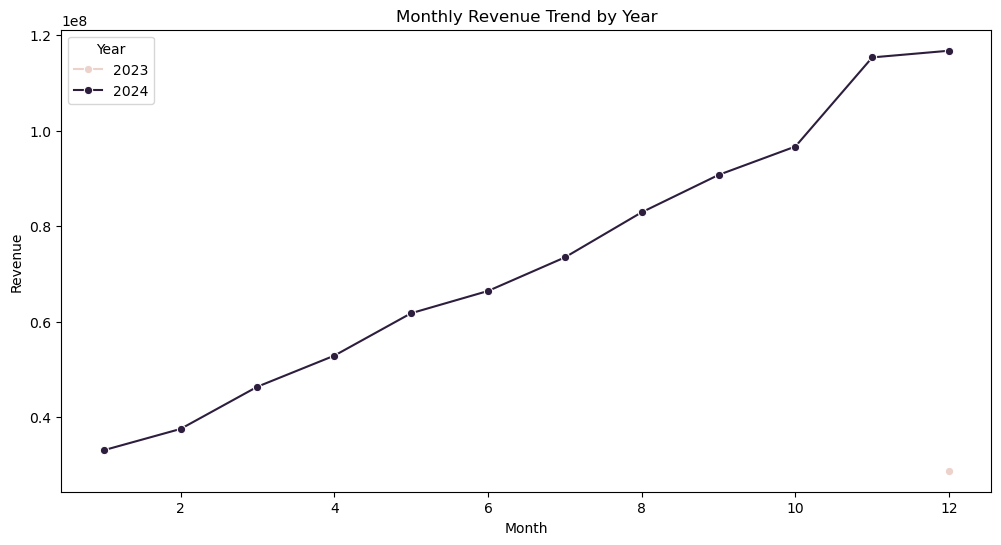

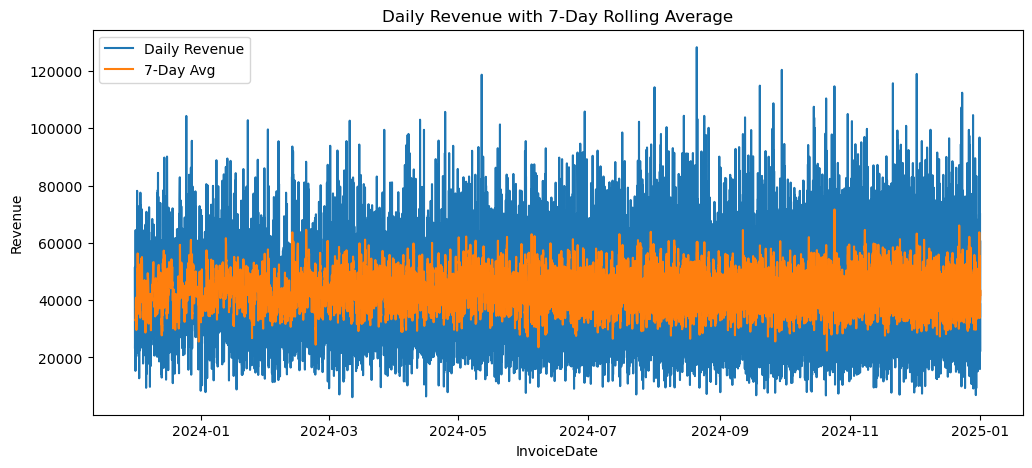

In [25]:
# Revenue by month and year
monthly_revenue = df.groupby(['Year','Month'], as_index=False)['Revenue'].sum()

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue', hue='Year', marker='o')
plt.title('Monthly Revenue Trend by Year')
plt.show()

df_daily = df.groupby('InvoiceDate')['Revenue'].sum().reset_index()
df_daily['Rolling7'] = df_daily['Revenue'].rolling(7).mean()

plt.figure(figsize=(12,5))
sns.lineplot(data=df_daily, x='InvoiceDate', y='Revenue', label='Daily Revenue')
sns.lineplot(data=df_daily, x='InvoiceDate', y='Rolling7', label='7-Day Avg')
plt.title('Daily Revenue with 7-Day Rolling Average')
plt.show()


### product level analysis

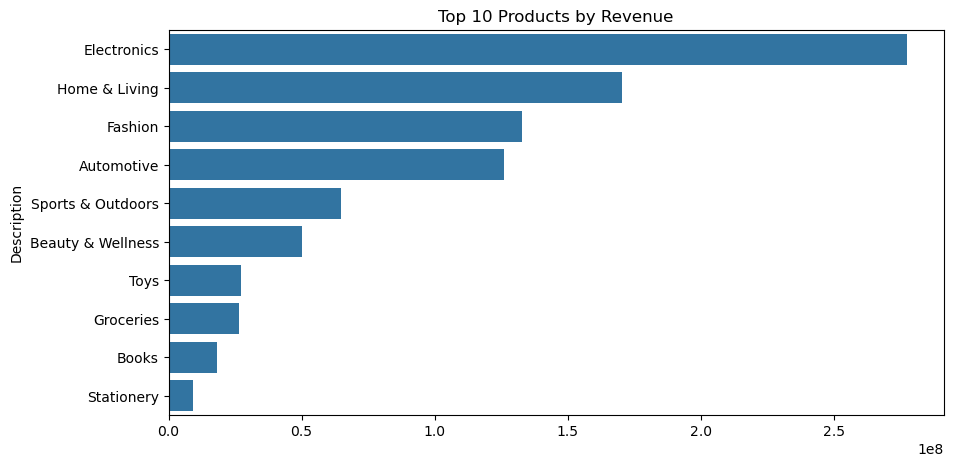

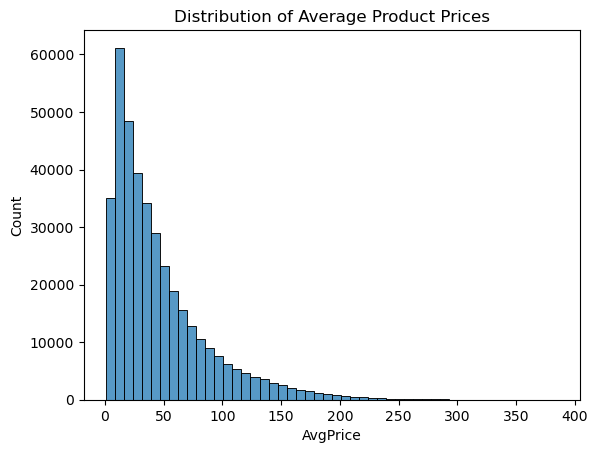

In [26]:
# Top products by revenue
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(y=top_products.index, x=top_products.values)
plt.title('Top 10 Products by Revenue')
plt.show()

# Average price per product
df['AvgPrice'] = df['Revenue'] / df['Quantity']
sns.histplot(df['AvgPrice'], bins=50)
plt.title('Distribution of Average Product Prices')
plt.show()


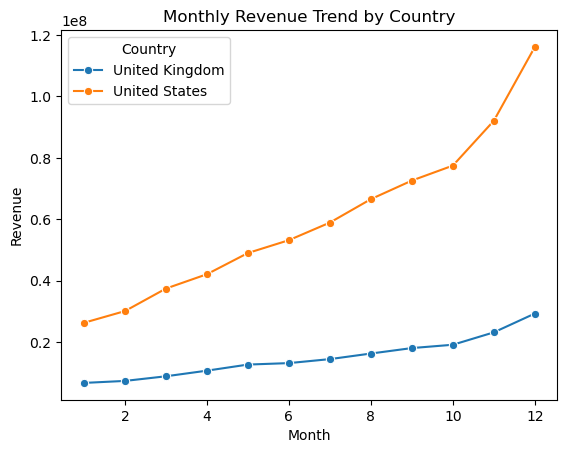

In [27]:
proSaleByMonth = (
    df.groupby(['Country', 'Month'], as_index=False)['Revenue']
      .sum()
)
sns.lineplot(data=proSaleByMonth, x='Month', y='Revenue', hue='Country', marker='o')
plt.title('Monthly Revenue Trend by Country')
plt.show()


### Monthly revenue trend
We have a significant increase in orders from the United States (US) than the United Kingdom(Uk) which has steady increase but not significant. In the US we have sales sharply increasing between October and December which almost balance the sale between January to June of the same year indicating potential festive season driven sales.

#### price demand relations

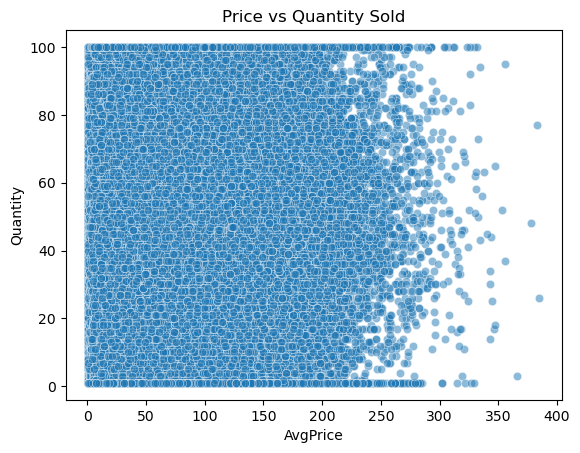

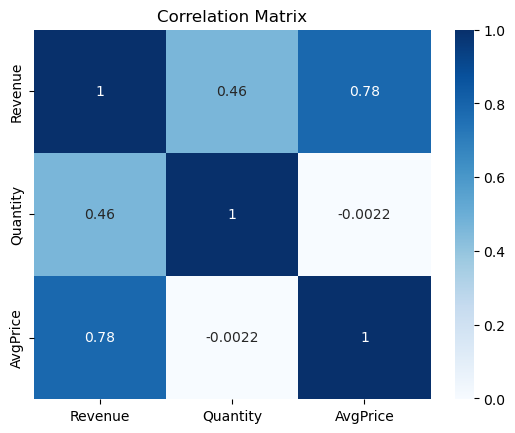

In [28]:
# Correlation between price and quantity
sns.scatterplot(data=df, x='AvgPrice', y='Quantity', alpha=0.5)
plt.title('Price vs Quantity Sold')
plt.show()

corr = df[['Revenue', 'Quantity', 'AvgPrice']].corr()
sns.heatmap(corr, annot=True, cmap='Blues')
plt.title('Correlation Matrix')
plt.show()


### price demand analysis

The correlation matrix showed a week relationship between quantity and revenue at 0.46, the higher the units sold, the higher the revenue indicating that we are selling lower quantities which will impact our revenue

Higher price leads to higher revenues caveat quantity sold is not dropping. Despite the lower quantity sold, our revenue to avg price has a positive relationship indicating we are at a convenient price range

However, the quantity and price correlation is significantly week showing that customers are not buying more items and potentially buying lower priced items.

### Customer segmentation analysis

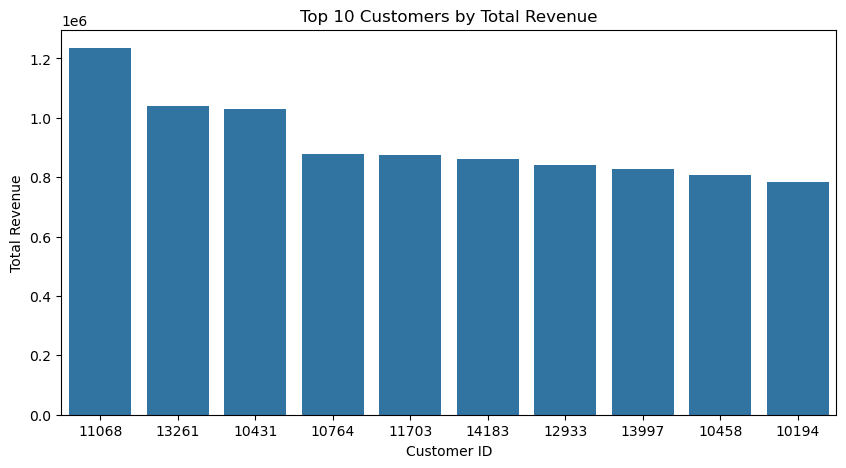

In [37]:
# Top customers by total revenue
top_customers = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(10,5))
sns.barplot(x=top_customers.index.astype(str), y=top_customers.values)
plt.title('Top 10 Customers by Total Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue')
plt.show()

top_qty_customers = df.groupby('CustomerID')['Quantity'].sum().sort_values(ascending=False).head(10)


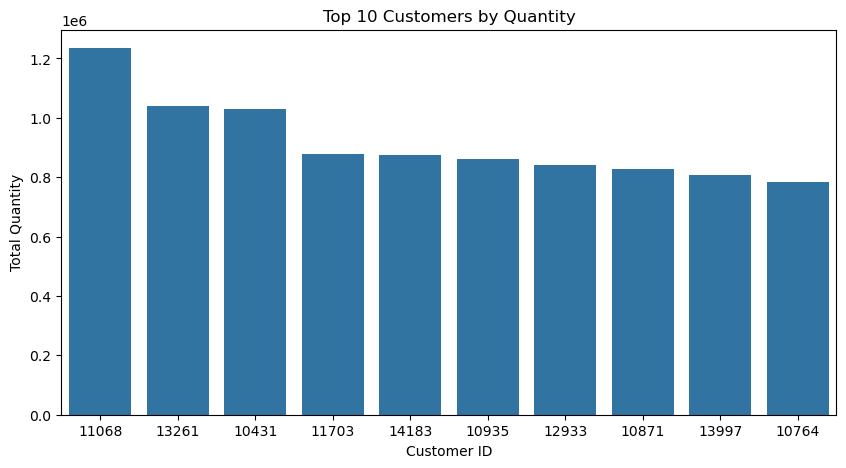

In [38]:
plt.figure(figsize=(10,5))
sns.barplot(x=top_qty_customers.index.astype(str), y=top_customers.values)
plt.title('Top 10 Customers by Quantity')
plt.xlabel('Customer ID')
plt.ylabel('Total Quantity')
plt.show()


#### RFM Analysis

In [40]:
# Latest purchase date in dataset
latest_date = df['InvoiceDate'].max()

# RFM aggregation
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (latest_date - x.max()).days,  # Recency
    'InvoiceNo': 'nunique',                                # Frequency
    'Revenue': 'sum'                                       # Monetary
}).reset_index()

# column renaming
rfm.columns = ['CustomerID', 'Recency', 'Frequency', 'Monetary']

# Score each metric 1–5 with 5 better
rfm['R_Score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_Score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

# Combine into a single RFM score
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)
rfm['RFM_Score'] = rfm[['R_Score', 'F_Score', 'M_Score']].astype(int).sum(axis=1)

rfm.head()


,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Segment,RFM_Score
0,10000,139,5,242993.87,1,3,4,134,8
1,10001,85,1,20841.75,2,1,1,211,4
2,10002,22,6,254693.19,4,4,4,444,12
3,10003,88,2,115314.08,2,1,2,212,5
4,10004,99,7,305794.35,2,4,4,244,10


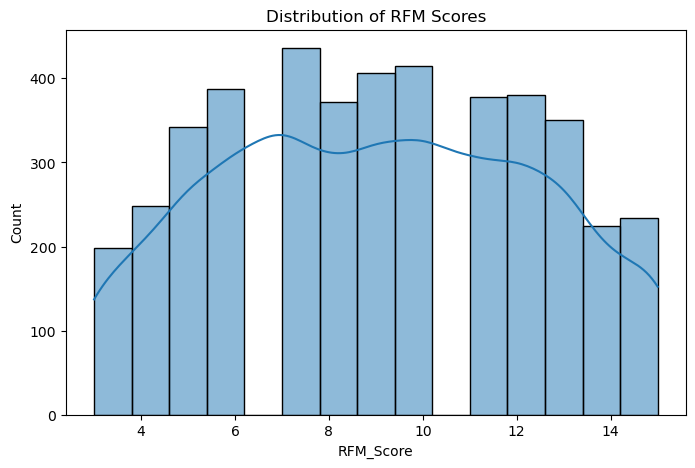

In [41]:
plt.figure(figsize=(8,5))
sns.histplot(rfm['RFM_Score'], bins=15, kde=True)
plt.title('Distribution of RFM Scores')
plt.show()


##### Creating Customer segmentation from RFM score

### RFM score analysis
We have a uniform distribution of the RFM score with customers peaking showed we have a high concentation of customers purchased recently between 6-12 and the recency with 7.5 been  the highest.  These showed most customers above 400 with more purchase midway through the year before this analysis and our to high spenders on the average of 200 customers

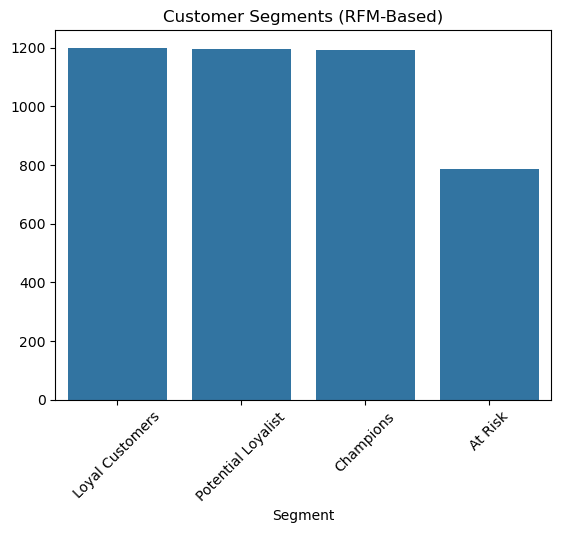

In [42]:
def segment(rfm):
    if rfm['RFM_Score'] >= 12:
        return 'Champions'
    elif rfm['RFM_Score'] >= 9:
        return 'Loyal Customers'
    elif rfm['RFM_Score'] >= 6:
        return 'Potential Loyalist'
    elif rfm['RFM_Score'] >= 3:
        return 'At Risk'
    else:
        return 'Lost'
    
rfm['Segment'] = rfm.apply(segment, axis=1)

segment_summary = rfm['Segment'].value_counts()
sns.barplot(x=segment_summary.index, y=segment_summary.values)
plt.title('Customer Segments (RFM-Based)')
plt.xticks(rotation=45)
plt.show()


#### Customer loyality
The segmentation of customers based on the RFM score showed we still stand a good chance to retain a significant number of our customers as Champions and loyal customers topped out equally while we have a significant number of customers at risk of been lost.

#### Churn and retention rate

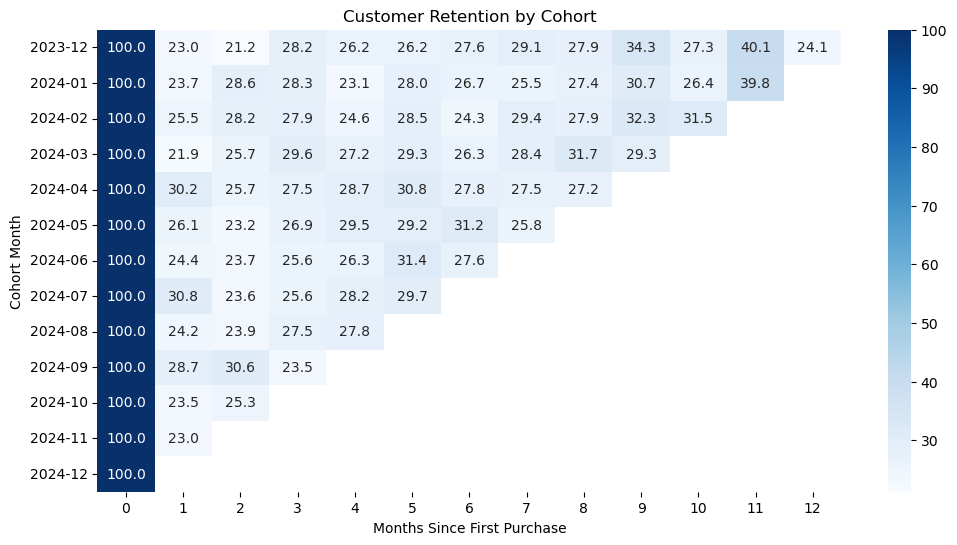

In [50]:
# Monthly customer retention
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Identify first purchase month per customer
first_purchase = df.groupby('CustomerID')['InvoiceMonth'].min().reset_index()
first_purchase.columns = ['CustomerID', 'CohortMonth']
# first_purchase['CohortMonth'] = first_purchase['CohortMonth'].dt.to_period('M')

# Merge back
df = df.merge(first_purchase, on='CustomerID', how='left')

# Create Cohort Index (months since first purchase)
def cohort_period(df):
    return (df['InvoiceMonth'] - df['CohortMonth']).apply(attrgetter('n'))

df['CohortIndex'] = cohort_period(df)

# Cohort analysis
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_pivot = cohort_data.pivot(index='CohortMonth', columns='CohortIndex', values='CustomerID')

# Convert to retention %
cohort_size = cohort_pivot.iloc[:,0]
retention = cohort_pivot.divide(cohort_size, axis=0) * 100

plt.figure(figsize=(12,6))
sns.heatmap(retention, annot=True, fmt=".1f", cmap='Blues')
plt.title('Customer Retention by Cohort')
plt.ylabel('Cohort Month')
plt.xlabel('Months Since First Purchase')
plt.show()


### Cohort analysis
Based on the cohot heat map, the sharp drop after the first purcahse in the range 21.9 - 30.8 suggest weak engagement leading to low repeat purchase rate. In November, we can see that 40% average repeat purchase occurred indicating a possible promotion or pre festive purchase. 

We have a steady decline in retention over the 12 months period showing that we are retaining fewer cohorts from later months of 2024 compared to Demcember 2023 to March 2024. 

Our churn point is shortly after the first purchase showing we need to ensure we retain customers following first purchase

In [42]:
### IN tut Customer seg

In [44]:
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [45]:
reference_date

Timestamp('2025-01-01 23:52:56')

In [48]:
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': pd.Series.nunique,
    'Revenue': 'sum'
}).reset_index()

In [49]:
####rename from above InvoiceDate == recency_days, InvoiceNo = frequency, Revenue = Monetary
rfm.columns = ['CustomerID', 'recency_days', 'frequency', 'monetary']

In [51]:
rfm.head()

,CustomerID,recency_days,frequency,monetary
0,10000,140,5,242993.87
1,10001,86,1,20841.75
2,10002,23,6,254693.19
3,10003,89,2,115314.08
4,10004,100,7,305794.35


In [52]:
from sklearn.preprocessing import StandardScaler

In [54]:
x = rfm[['recency_days', 'frequency', 'monetary']].copy()
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [57]:
x_scaled

array([[ 1.07915363,  0.06017119,  0.25019975],
       [ 0.26375028, -1.14933883, -1.26817781],
       [-0.68755362,  0.36254869,  0.33016291],
       ...,
       [-0.37045232, -1.14933883, -1.05706758],
       [-0.86875437,  1.57205871,  1.76664742],
       [ 0.20335003,  0.06017119,  0.20268637]])

In [59]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [61]:
inertia = []
sil_scores = []
k_range = range(2, 11)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels=km.fit_predict(x_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(x_scaled, labels))

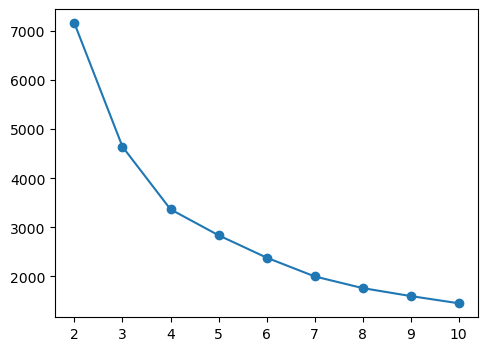

In [65]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(k_range, inertia, marker='o')
plt.show()

In [66]:
###use yellow brick to get clear elbow
from yellowbrick.cluster import KElbowVisualizer

KElbowVisualizer(ax=<Axes: >, estimator=KMeans(n_clusters=9, random_state=42),
                 k=(2, 10))

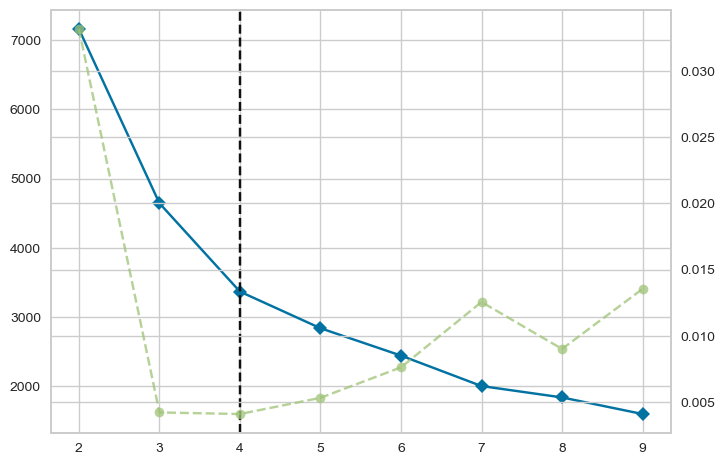

In [67]:
model=KMeans(random_state=42)
visualizer=KElbowVisualizer(model, k=(2,10))
visualizer.fit(x_scaled)

In [69]:
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(x_scaled)

KMeans(n_clusters=4, random_state=42)

In [73]:
rfm['Clusters'] = kmeans.labels_
rfm.head()

,CustomerID,recency_days,frequency,monetary,Clusters
0,10000,140,5,242993.87,2
1,10001,86,1,20841.75,1
2,10002,23,6,254693.19,0
3,10003,89,2,115314.08,1
4,10004,100,7,305794.35,0


In [75]:
cluster_profile =rfm.groupby('Clusters').agg({
    'recency_days': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'CustomerID': 'count'
}).rename(columns={'CustomerID': 'numCustomers'}).round(1)

In [76]:
cluster_profile

,recency_days,frequency,monetary,numCustomers
Clusters,,,,
0,47.1,6.3,269730.0,1367
1,45.0,2.4,99169.9,1733
2,186.8,2.9,125700.8,719
3,41.5,11.2,490713.6,553


In [79]:
#### better is low recency (most recent purchase), frequency = high and monetary high)
cluster_name = {
    3: 'v-VIPs',
    0: 'VIPs',
    1: 'Loyal Regulars',
    2: 'At Risk/Lost'
}



In [81]:
cluster_profile['Segment'] = cluster_profile.index.map(cluster_name)

In [82]:
cluster_profile.head()

,recency_days,frequency,monetary,numCustomers,Segment
Clusters,,,,,
0,47.1,6.3,269730.0,1367,VIPs
1,45.0,2.4,99169.9,1733,Loyal Regulars
2,186.8,2.9,125700.8,719,At Risk/Lost
3,41.5,11.2,490713.6,553,v-VIPs


In [83]:
cluster_profile.columns

Index(['recency_days', 'frequency', 'monetary', 'numCustomers', 'Segment'], dtype='object')

In [84]:
df_plot=cluster_profile.copy()

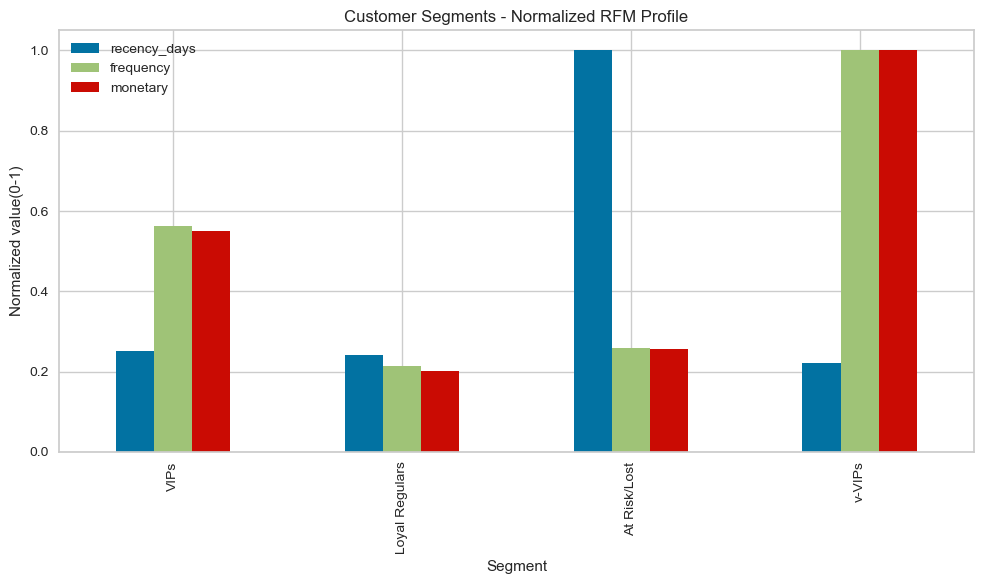

In [92]:
df_plot[['recency_days', 'frequency', 'monetary']] = (
    df_plot[['recency_days', 'frequency', 'monetary']].apply(lambda x : x/x.max())
)

df_plot.set_index('Segment')[['recency_days', 'frequency', 'monetary']].plot(kind='bar', figsize=(10,6))
plt.title('Customer Segments - Normalized RFM Profile')
plt.ylabel('Normalized value(0-1)')
plt.tight_layout()
plt.show()